Setup & libraries installation

In [1]:
import numpy as np

![WhatsApp Image 2026-03-06 at 21.18.05.jpeg](<attachment:WhatsApp Image 2026-03-06 at 21.18.05.jpeg>)
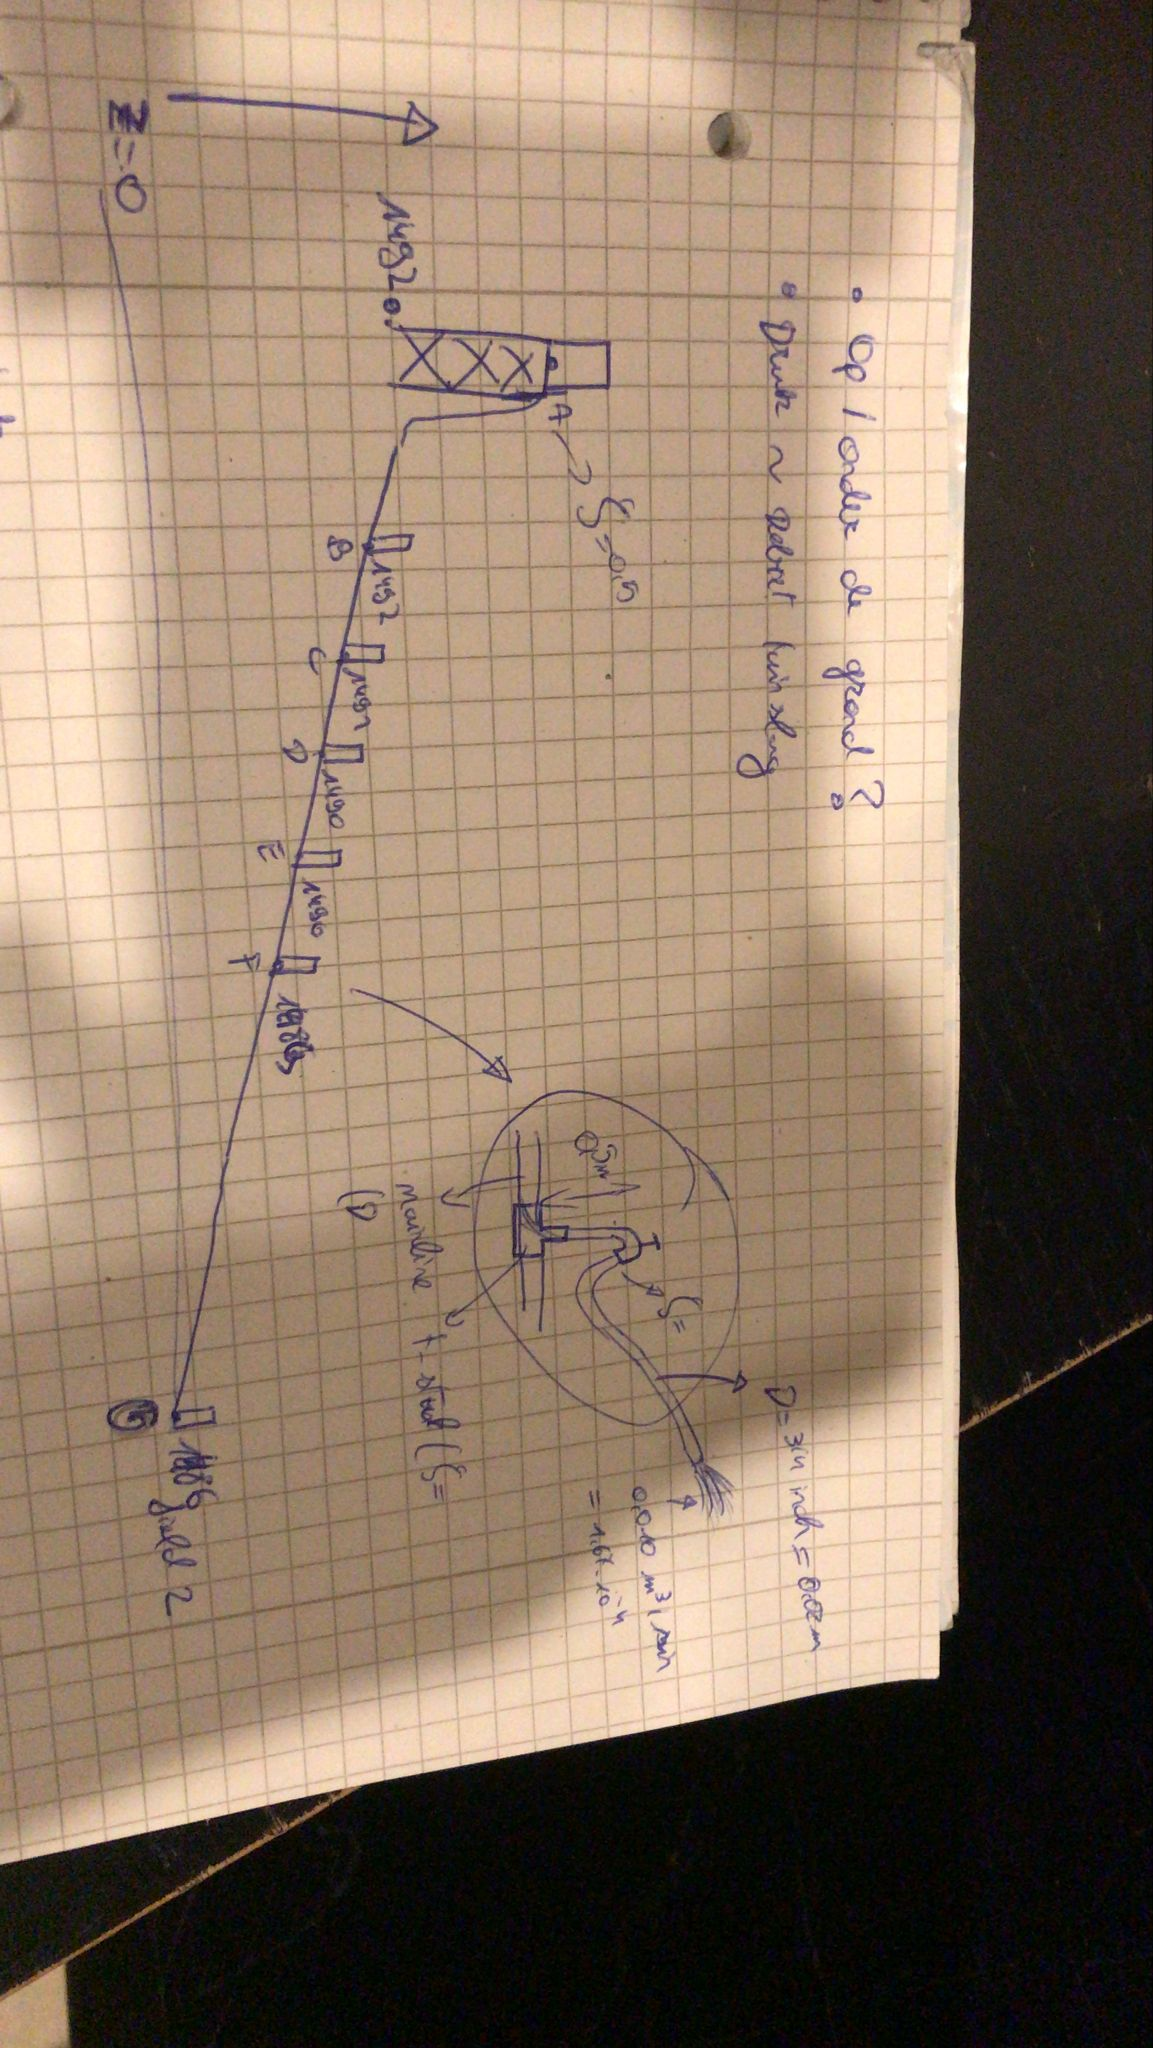

Defining variables

In [2]:
ha, hb, hc, hd, he, hf, hg = 1493.87 , 1490.67, 1486.58, 1486.58, 1485.05, 1485.05, 1481.53 # (m)
h_ref = hg
tap_height = 1.5

loss_t_section, loss_inlet = 1, 0.5 # (/)
water_density, dyn_visc, kin_visc =  998, 1.307e-3, 1.307e-6
Qdesired = 1.67e-4 # m3 /s ------- =10 l / min
ab, bc, cd, de, ef, fg = 10,10,10,10,10,40 # (m)
l_hose = 15 #m
g = 9.81

#lists
heights = [hb, hc, hd, he, hf, hg] #ha hebben we hier niet nodig
distances = [ab, bc, cd, de, ef, fg]

#garden hose 3/4 inch
D_hose = 0.019 #(m)
e_hose = 0.0015 *10e-3 #(m)
A_hose = D_hose**2 * np.pi / 4
U_hose = Qdesired / A_hose

#hdpe mainline 3/4 inch
D_main = 0.019 #(m)
e_main = 0.000003 #(m)
A_main = D_main**2 * np.pi / 4
U_main = Qdesired / A_main

In [3]:
print('Speed hose: ' + str(round(U_hose, 2)) + ' m/s \nSpeed mainline: ' + str(round(U_main,2)) + ' m/s')

Speed hose: 0.59 m/s 
Speed mainline: 0.59 m/s


Often used functions

In [13]:
def Reynold(Q, D):
    Re = (4 * Q) / (np.pi * D * kin_visc)
    return(Re)


def WhiteColeBrook(Re, e, D):
    f = 0.020
    verschil = 1
    while(verschil > 0.0001): 
        fnew = 1 / (-2 * np.log10 (2.51 / (Re * np.sqrt(f)) + e / (3.7 * D)))**2
        verschil = abs(f - fnew)
        f = fnew
        
    return(f)


def CalculateHead(n, h_end,  Qdesired, D_hose, D_main): #amount of segments, height of endpoint
    main_losses = 0
    
    Re_hose = Reynold(Qdesired, D_hose)
    Re_main = Reynold(Qdesired, D_main)
    
    f_hose = WhiteColeBrook(Re_hose, e_hose, D_hose)
    #print("f_hose is: " + str(f_hose))
    f_main = WhiteColeBrook(Re_main, e_main, D_main)
    #print("f_main is: " + str(f_main))

    
    for i in range(n):
        main_losses += (f_main * distances[i]  * U_main**2) / (D_main * 2 * g)
      #  print('Main losses segment ' + str(i) + ': ' + str(round(main_losses, 2)) + ' m')

    hose_losses = (f_hose * l_hose  * U_hose**2) / (D_hose * 2 * g)
    local_losses = (loss_inlet + loss_t_section * n) * (Qdesired**2) / (A_main**2 * 2 * g) # #n T-sections

    
  #  print('Hose losses ' + str(round(hose_losses, 2)) + ' m')
   # print('Local losses ' + str(round(local_losses, 2)) + ' m')


    total_losses = main_losses + hose_losses + local_losses
    total_head = h_end + Qdesired**2 / (A_hose**2 * 2 * g) + total_losses + tap_height
    return(total_head)


Calculations

In [5]:
Re_hose = Reynold(Qdesired, D_hose)
Re_main = Reynold(Qdesired, D_main)

Re_hose, Re_main

(8562.437239591358, 8562.437239591358)

In [7]:


f_hose = WhiteColeBrook(Re_hose, e_hose, D_hose)
print(f_hose)

f_main = WhiteColeBrook(Re_main, e_main, D_main)
print(f_main)


0.033293316612255736
0.03240790672099209


Voorlopig uitgaande van een tuinslang zonder speciaal opzetstuk

In [19]:
i = 0
points = ['B', 'C', 'D', 'E', 'F', 'G']
for height in heights:
    z = CalculateHead(1, height, Qdesired, D_hose, D_main)
    print('Height water tower needed for' + points[i] + '= ' + str(round(z - ha, 2)))
    i += 1



Height water tower needed forB= -0.89
Height water tower needed forC= -4.98
Height water tower needed forD= -4.98
Height water tower needed forE= -6.51
Height water tower needed forF= -6.51
Height water tower needed forG= -10.03


De tank moet dus niet op een heel hoog verhoog staan om te werken

Wat als 2, 3 ,4 of taps tegelijk aanstaan?

In [27]:
for i in range(2, 6):
    print('For using ' + str(i) + " taps at the same time we get the following heights")
    j = 0
    for height in heights:
        z = CalculateHead(1, height, Qdesired * i , D_hose, D_main)
        print('Height water tower needed for' + points[j] + '= ' + str(round(z - ha, 2)))
        j += 1




For using 2 taps at the same time we get the following heights
Height water tower needed forB= -0.87
Height water tower needed forC= -4.96
Height water tower needed forD= -4.96
Height water tower needed forE= -6.49
Height water tower needed forF= -6.49
Height water tower needed forG= -10.01
For using 3 taps at the same time we get the following heights
Height water tower needed forB= -0.71
Height water tower needed forC= -4.8
Height water tower needed forD= -4.8
Height water tower needed forE= -6.33
Height water tower needed forF= -6.33
Height water tower needed forG= -9.85
For using 4 taps at the same time we get the following heights
Height water tower needed forB= -0.43
Height water tower needed forC= -4.52
Height water tower needed forD= -4.52
Height water tower needed forE= -6.05
Height water tower needed forF= -6.05
Height water tower needed forG= -9.57
For using 5 taps at the same time we get the following heights
Height water tower needed forB= -0.05
Height water tower needed f

We conclude that the system will still work when using all the taps at the same time, the calculation above is a simplification, but a conservative one which insures the proper functioning of the system